In [239]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [240]:
pd.set_option('display.max_columns', None)

In [241]:
df = pd.read_csv("../data/raw/churn_data.csv")

In [242]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### drop customerID column

In [243]:
df.drop(columns=["customerID"], inplace=True)

In [244]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [245]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

### convert TotalCharges to numeric datatype

In [246]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [247]:
df['TotalCharges'].isna().sum()

np.int64(11)

#### fill null TotalCharges with monthlyCharges

In [248]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

In [249]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [250]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

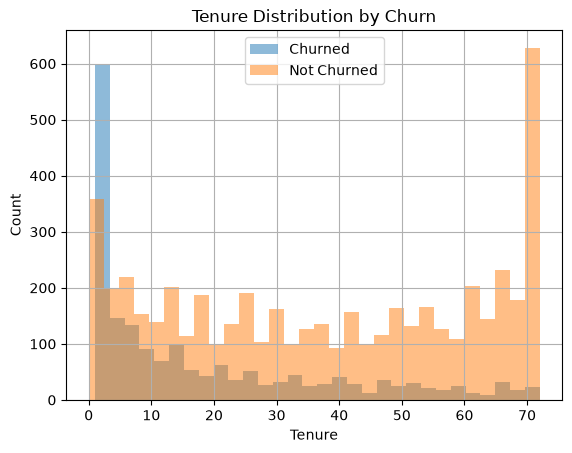

In [251]:
df[df['Churn'] == 'Yes']['tenure'].hist(alpha=0.5, label='Churned', bins=30)
df[df['Churn'] == 'No']['tenure'].hist(alpha=0.5, label='Not Churned', bins=30)
plt.xlabel('Tenure')
plt.ylabel('Count')
plt.legend()
plt.title('Tenure Distribution by Churn')
plt.show()

### Binning tenure feature

#### - Hypothesis: Churn risk isn't linear across tenure. A customer's first few months are typically much riskier than year 3.

In [252]:
tenure_bins = [-np.inf, 6, 12, 24, np.inf]
tenure_labels = ['0-6mo', '6-12mo', '1-2yr', '2+yr']

df['tenure_bucket'] = pd.cut(df['tenure'], bins=tenure_bins, labels=tenure_labels)

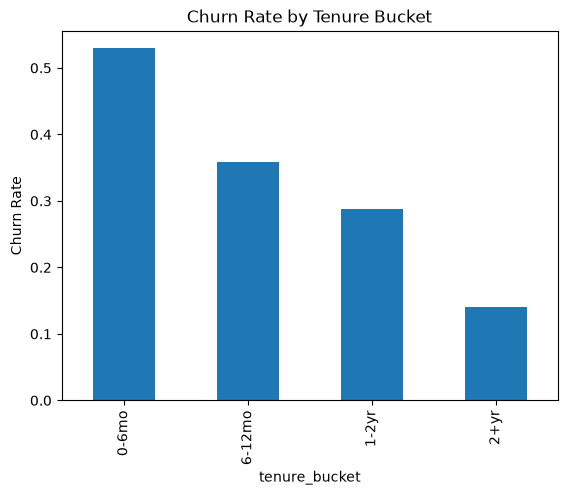

In [253]:
churn_rate_by_bucket = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())
churn_rate_by_bucket.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tenure Bucket')
plt.show()

In [254]:
df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

tenure_bucket
0-6mo     0.529372
6-12mo    0.358865
1-2yr     0.287109
2+yr      0.140360
Name: Churn, dtype: float64

- churn rate is higher for 0-6 months than for 2+yrs. Therefore, hypothesis is true

In [255]:
print(df.query("Churn == 'Yes' and tenure_bucket == '0-6mo'").shape[0])

784


In [256]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   str     
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   str     
 3   Dependents        7043 non-null   str     
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   str     
 6   MultipleLines     7043 non-null   str     
 7   InternetService   7043 non-null   str     
 8   OnlineSecurity    7043 non-null   str     
 9   OnlineBackup      7043 non-null   str     
 10  DeviceProtection  7043 non-null   str     
 11  TechSupport       7043 non-null   str     
 12  StreamingTV       7043 non-null   str     
 13  StreamingMovies   7043 non-null   str     
 14  Contract          7043 non-null   str     
 15  PaperlessBilling  7043 non-null   str     
 16  PaymentMethod     7043 non-null   s

### - avg monthly spend feature

In [257]:
df['avg_monthly_spend'] = df['TotalCharges'] / df['tenure'].replace(0,1)

In [258]:
df[['MonthlyCharges', 'avg_monthly_spend']].corr()

,MonthlyCharges,avg_monthly_spend
MonthlyCharges,1.000000,0.996244
avg_monthly_spend,0.996244,1.000000


In [259]:
churn_binary = (df['Churn'] == 'Yes').astype(int)
df[['MonthlyCharges', 'avg_monthly_spend']].corrwith(churn_binary)

MonthlyCharges       0.193356
avg_monthly_spend    0.192531
dtype: float64

- MonthlyCharges correlates with churn at 0.193, and avg_monthly_spend at 0.193. this shows that avg_monthly_spend feature is redundant as it shows almost the same thing as MonthlyCharges.
therefore, drop avg_monthly_spend as It's not adding any new signal beyond what MonthlyCharges already provides

In [260]:
df.drop(columns=["avg_monthly_spend"], inplace=True)

### total services subscribed feature

In [261]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['total_services'] = (df[service_cols] == 'Yes').sum(axis=1)

In [262]:
df.groupby('total_services', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

total_services
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

In [263]:
df['has_internet'] = (df['InternetService'] != 'No').astype(int)

In [264]:
df[df['has_internet'] == 1].groupby('total_services', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

total_services
0    0.522367
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64

In [265]:
df.groupby('has_internet')['Churn'].apply(lambda x: (x == 'Yes').mean())

has_internet
0    0.074050
1    0.318289
Name: Churn, dtype: float64

- customers who dont have internet dont have any addons as well becuse all those services need internet
- customers who have no internet service have been observed to churn less
- customers who have internet service but no addons were observed to churn more and the churn rate decreases as number of addons increases

### contract-to-payment risk combo

In [266]:
df['high_risk_combo'] = ((df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')).astype(int)

In [267]:
churn_binary = (df['Churn'] == 'Yes').astype(int)

# check the combo feature vs each factor alone
print(df.groupby('high_risk_combo', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()))
print(df.groupby('Contract', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()))
print(df.groupby('PaymentMethod', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()))

high_risk_combo
0    0.168496
1    0.537297
Name: Churn, dtype: float64
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64


- customers with both contract type month-to-month and payment method as electronic check are observed to churn more when compared to those who only have  contract type month-to-month or payment method as electronic check

### charges relative to internet service type

In [268]:
df['charge_vs_service_avg'] = df.groupby('InternetService')['MonthlyCharges'].transform(lambda x: x - x.mean())

In [269]:
df[['MonthlyCharges', 'charge_vs_service_avg']]

,MonthlyCharges,charge_vs_service_avg
0,29.85,-28.252169
1,56.95,-1.152169
2,53.85,-4.252169
3,42.30,-15.802169
4,70.70,-20.800129
...,...,...
7038,84.80,26.697831
7039,103.20,11.699871
7040,29.60,-28.502169
7041,74.40,-17.100129


In [270]:
churn_binary = (df['Churn'] == 'Yes').astype(int)
df['charge_vs_service_avg'].corr(churn_binary)

np.float64(-0.21695839218416754)

In [271]:
df[['MonthlyCharges', 'charge_vs_service_avg']].corr()

,MonthlyCharges,charge_vs_service_avg
MonthlyCharges,1.000000,0.423441
charge_vs_service_avg,0.423441,1.000000


- charge_vs_service_avg tells you whether a customer is a relative overpayer or underpayer compared to others with the same type of internet plan and it turns out underpayers (relative to their peer group) are slightly more likely to churn than overpayers

## Encoding

In [272]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_bucket,total_services,has_internet,high_risk_combo,charge_vs_service_avg
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-6mo,1,1,1,-28.252169
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,2+yr,2,1,0,-1.152169
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-6mo,2,1,0,-4.252169
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2+yr,3,1,0,-15.802169
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-6mo,0,1,1,-20.800129


In [273]:
# encode target column using Label Encoding
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])

# encode binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, "No": 0})

# on-hot encoding for multi-category columns
df = pd.get_dummies(df, columns=['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
                                  'Contract', 'PaymentMethod', 'tenure_bucket'], drop_first=True)

In [274]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [275]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   PaperlessBilling                       7043 non-null   int64  
 6   MonthlyCharges                         7043 non-null   float64
 7   TotalCharges                           7043 non-null   float64
 8   Churn                                  7043 non-null   int64  
 9   total_services                         7043 non-null   int64  
 10  has_internet                           7043 non-null   int64  
 11  high_risk_combo

## Model Training

In [276]:
# Spilt dataset into training and testing data
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [277]:
# Train Logistic Regression model
model_v2 = LogisticRegression()
model_v2.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [278]:
y_pred = model_v2.predict(X_test_scaled)
y_proba = model_v2.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

AUC: 0.8439639360355473


**Conclusion:** Engineered features produced a negligible net effect on Logistic Regression — AUC improved marginally, while threshold-based metrics were essentially flat. This suggests these features (particularly the interaction and relative-comparison features) may be better exploited by non-linear models, to be tested in Step 2.3.

In [279]:
df.to_csv('../data/processed/churn_engineered.csv', index=False)